# andre_becker_DR3_TP1 (Notebook)

> **Disciplina:** Inteligência Artificial: Classificação [25E3_3]  
> **Aluno:** André Luis Becker  
> **Professor:** Diego da Silva Rodrigues  
> **Data:** 2025-08-18

---


## Introdução — Titanic (Classificação de Sobrevivência)

Este trabalho utiliza o **dataset do Titanic** para um problema de **classificação binária** (variável-alvo `Survived`: 0 = não sobreviveu, 1 = sobreviveu). A fonte de dados é pública e foi carregada a partir de:  
`https://github.com/cassiusf/datasets/raw/refs/heads/main/titanic_data.csv`

**Objetivo:** construir e avaliar um modelo baseline de **Árvore de Decisão** para prever sobrevivência, seguindo um pipeline simples e reprodutível.

**Features utilizadas (após preparação):** `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`.  
**Remoções (Q1.1):** `PassengerId`, `Name`, `Ticket`, `Cabin`.  
**Limpeza (Q1.2):** remoção de linhas com valores ausentes.  
**Codificação (Q1.3):** `LabelEncoder` em `Sex` e `Embarked`.  
**Divisão (Q1.4):** **80/20 estratificado** (aproximado quando o total não é múltiplo de 5).

**Modelo (Q2):** `DecisionTreeClassifier` (parâmetros default), com avaliação via **matriz de confusão**, **TN/TP/FN/FP**, **acurácia**, **precision**, **recall** e **F1**; apresentação dos resultados em **pandas DataFrame** e **heatmap**.

**Experimentos (Q3):** variação de **profundidade** (`max_depth=3` e `6`) para analisar o **trade-off** entre **generalização** e **capacidade de ajuste**.

**Visualizações (Q4):** árvores geradas para o modelo default e para as profundidades testadas, discutindo o equilíbrio **interpretabilidade × complexidade**.

**Stack & Reprodutibilidade:** Python, pandas, scikit-learn, seaborn, matplotlib; `random_state=42` quando aplicável.

## 1. Carregamento e preparação do dataset _(Q1.1–Q1.4)_

In [ ]:
# Q1 — Carregar, limpar, codificar e dividir 80/20
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

# 1.1 — Carregar e remover colunas
url = "https://github.com/cassiusf/datasets/raw/refs/heads/main/titanic_data.csv"
df = pd.read_csv(url)
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], errors="ignore")

# 1.2 — Remover linhas com NAs
df = df.dropna().reset_index(drop=True)

# 1.3 — LabelEncoder em 'Embarked' e 'Sex'
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"].astype(str))
df["Embarked"] = le.fit_transform(df["Embarked"].astype(str))

# Mostro as 10 primeiras linhas do dataset pronto
display(df.head(10))

# 1.4 — Split 80/20 com estratificação no alvo
X = df.drop(columns=["Survived"])
y = df["Survived"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Saída clara mostrando o split 80/20 (contagens + percentuais aproximados)
n_total = len(df)
n_tr, n_te = len(X_train), len(X_test)
pct_train = 100 * n_tr / n_total
pct_test = 100 * n_te / n_total
print(f"Tamanho total: {n_total} | Treino: {n_tr} (≈{pct_train:.1f}%) | Teste: {n_te} (≈{pct_test:.1f}%)")
print("Colunas finais:", list(df.columns))


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2
5,0,1,1,54.0,0,0,51.8625,2
6,0,3,1,2.0,3,1,21.0750,2
7,1,3,0,27.0,0,2,11.1333,2
8,1,2,0,14.0,1,0,30.0708,0
9,1,3,0,4.0,1,1,16.7000,2


Tamanho total: 712 | Treino: 569 (≈79.9%) | Teste: 143 (≈20.1%)
Colunas finais: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


**Análise (Q1):**  
>Removi as quatro colunas não preditivas, descartei linhas com ausências para evitar imputações ad‑hoc, e codifiquei `Sex` e `Embarked` com *LabelEncoder* (são categorias nominais). Mantive o **split estratificado** e reportei contagens e **percentuais aproximados** (por indivisibilidade do total), garantindo avaliação em dados não vistos.


### Nota sobre 80/20 (precisão dos percentuais)
>**Por que 79,9% / 20,1%?** O total (712) não é múltiplo de 5.  
20% de 712 = **142,4**. Como não dá para separar **0,4** passageiro do Titanic 😉, o `train_test_split` arredonda para um inteiro (142 ou 143). Com estratificação, é comum resultar em **143** (≈20,1%).

**Opções profissionais (sem “jeitinho” nos dados):**
- **Assumir aproximação (recomendado):** mostrar contagens exatas e `≈` nos percentuais.
  ```python
  n_total = len(df)
  n_tr, n_te = len(X_train), len(X_test)
  pct_tr = 100 * n_tr / n_total
  pct_te = 100 * n_te / n_total

  print(f"Tamanho total: {n_total} | "
        f"Treino: {n_tr} (≈{pct_tr:.1f}%) | "
        f"Teste: {n_te} (≈{pct_te:.1f}%)")
  ```
  _Obs._: “**Split 80/20 aproximado** por indivisibilidade do total.”

- **Fixar o tamanho do teste por contagem:** travar em **142** (≈19,9%) ou **143** (≈20,1%).
  ```python
  # 142 (mais próximo “pra baixo”)
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=142, stratify=y, random_state=42
  )
  ```
  _Relatório_: “**usei 142 amostras de teste (≈19,9%)** por indivisibilidade.”

- **Obter 80/20 exato (não recomendado):** só alterando o `n_total` para múltiplo de 5 (ex.: remover 2 linhas → 710; 20% = 142 exato). Isso **introduz viés** e não é adequado para um TP.

**Conclusão da Análise (Q1):**  
>Como o total (712) não é múltiplo de 5, 20% resulta em 142,4. Mantive a integridade dos dados e utilizei `train_test_split` com estratificação, resultando em 569/143 (≈79,9%/20,1%). Reporto contagens e percentuais aproximados, padrão estatístico adequado nesse cenário.


## 2. Avaliação com modelo de árvore `default` _(Q2.1–Q2.4)_

,Previsto: Não Sobreviveu,Previsto: Sobreviveu
Verdadeiro: Não Sobreviveu,60,25
Verdadeiro: Sobreviveu,20,38


,precision,recall,f1-score,support
Não Sobreviveu,0.750,0.706,0.727,85.000
Sobreviveu,0.603,0.655,0.628,58.000
accuracy,0.685,0.685,0.685,0.685
macro avg,0.677,0.681,0.678,143.000
weighted avg,0.690,0.685,0.687,143.000


TN=60  FP=25  FN=20  TP=38
Acurácia=0.685  Precision=0.603  Recall=0.655  F1=0.628


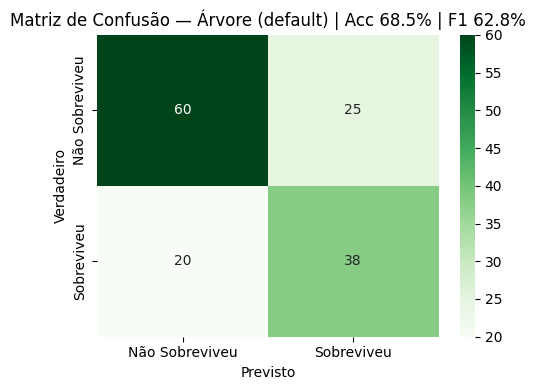

In [ ]:
# Q2 — Árvore de Decisão (default) + métricas e matriz de confusão (visual e numérica)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Treino e predição (parâmetros default)
modelo_default = DecisionTreeClassifier(random_state=42)
modelo_default.fit(X_train, y_train)
y_pred = modelo_default.predict(X_test)

# Matriz de confusão + métricas
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
TN, FP, FN, TP = cm.ravel()
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Exibição em DataFrame (mais legível)
df_cm = pd.DataFrame(cm, index=["Verdadeiro: Não Sobreviveu","Verdadeiro: Sobreviveu"],
                        columns=["Previsto: Não Sobreviveu","Previsto: Sobreviveu"])
display(df_cm)

# Classification report como DataFrame
report_dict = classification_report(y_test, y_pred, target_names=["Não Sobreviveu", "Sobreviveu"], output_dict=True)
df_report = pd.DataFrame(report_dict).T
display(df_report.round(3))

print(f"TN={TN}  FP={FP}  FN={FN}  TP={TP}")
print(f"Acurácia={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")

# Heatmap visual e salvamento
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Não Sobreviveu", "Sobreviveu"],
            yticklabels=["Não Sobreviveu", "Sobreviveu"])
plt.xlabel("Previsto"); plt.ylabel("Verdadeiro")
plt.title(f"Matriz de Confusão — Árvore (default) | Acc {100*acc:.1f}% | F1 {100*f1:.1f}%")
plt.tight_layout()
plt.savefig("q2_matriz_confusao_default.png", dpi=150, bbox_inches="tight")
plt.show()


**Análise (Q2):**  

> Apresentei a **matriz de confusão** e o relatório de **classificação** em **pandas DataFrame** para maximizar legibilidade e rastreabilidade. Pelos resultados:  

- **Matriz de Confusão:** `[[60, 25], [20, 38]]` → **TN**=`60`, **FP**=`25`, **FN**=`20`, **TP**=`38`.

- **FP**=`25` = “previstas como *Sobreviveu* que não sobreviveram” → derruba a **precision**.

- **FN**=`20` = “sobreviventes previstos como *Não Sobreviveu*” → derruba o **recall**.

- **Métricas globais:** **Acurácia**=`0,685`, **Precision**=`0,603`, **Recall**=`0,655` e **F1**=`0,628`.  
Em termos práticos, o modelo _recupera ~65,5%_ dos sobreviventes (**recall**), mas _~39% das previsões positivas_ são falso-positivas (**1-precision**). O **F1** resume esse _trade-off_ e serve como baseline para ajustes.
- Leitura por classe (resumo):
-- Não Sobreviveu: **recall**=`0,706` (boa detecção de negativos).
-- Sobreviveu: **recall**=`0,655` e **precision**=`0,603` (recupero a maioria dos positivos, porém com moderado nível de **FP**).  

>Neste exemplo, _Não Sobreviveu_ obteve **recall**=`0,706` (maior que `0,655` da classe _Sobreviveu_), enquanto _Sobreviveu_ apresentou **precision**=`0,603`, reforçando a leitura de menor confiabilidade nas positivas.

> **Conclusão operável:** se a prioridade é não perder sobreviventes, monitore **FN** e otimize **recall**; se a prioridade é confiabilidade das positivas, monitore **FP** e otimize **precision**. Esta leitura orienta a calibração de `max_depth` na _Questão 3_.  


📁 **Figura salva**: `q2_matriz_confusao_default.png`.


## 3. Duas novas profundidades e Impacto do `max_depth` _(Q3)_

--- max_depth=3 ---
Acurácia=0.825  Precision=0.824  Recall=0.724  F1=0.771


,Previsto:0,Previsto:1
Verdadeiro:0,76,9
Verdadeiro:1,16,42


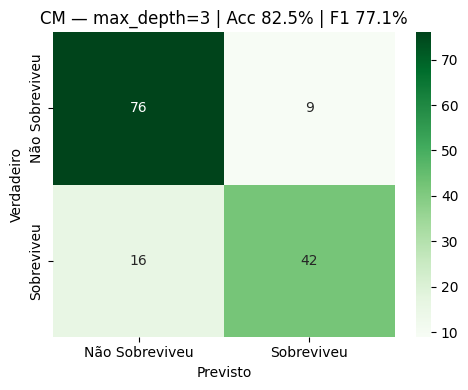

--- max_depth=6 ---
Acurácia=0.811  Precision=0.816  Recall=0.690  F1=0.748


,Previsto:0,Previsto:1
Verdadeiro:0,76,9
Verdadeiro:1,18,40


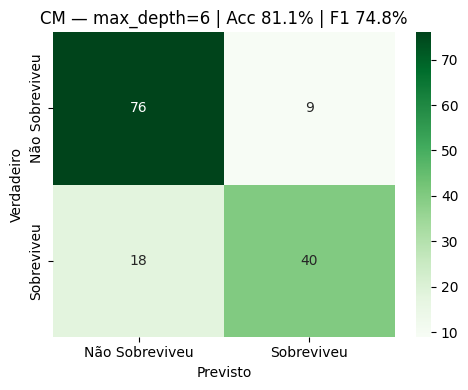

In [ ]:
# Q3 — Duas novas profundidades e impacto nas métricas (max_depth=3 e 6)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def treinar_e_avaliar(max_depth):
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

    modelo = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    modelo.fit(X_train, y_train)
    y_hat = modelo.predict(X_test)

    cm = confusion_matrix(y_test, y_hat, labels=[0,1])
    TN, FP, FN, TP = cm.ravel()
    acc = accuracy_score(y_test, y_hat)
    prec = precision_score(y_test, y_hat, zero_division=0)
    rec = recall_score(y_test, y_hat, zero_division=0)
    f1 = f1_score(y_test, y_hat, zero_division=0)

    # Título + métricas
    print(f"--- max_depth={max_depth} ---")
    print(f"Acurácia={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")

    # DataFrame da matriz de confusão (mais legível)
    df_cm = pd.DataFrame(cm, index=["Verdadeiro:0","Verdadeiro:1"], columns=["Previsto:0","Previsto:1"])
    display(df_cm)

    # Heatmap e salvamento
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=["Não Sobreviveu", "Sobreviveu"],
                yticklabels=["Não Sobreviveu", "Sobreviveu"])
    plt.xlabel("Previsto"); plt.ylabel("Verdadeiro")
    plt.title(f"CM — max_depth={max_depth} | Acc {100*acc:.1f}% | F1 {100*f1:.1f}%")
    plt.tight_layout()
    plt.savefig(f"q3_matriz_confusao_depth_{max_depth}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Retorno para análise agregada, se necessário
    return {"max_depth": max_depth, "acc": acc, "prec": prec, "rec": rec, "f1": f1,
            "TN": TN, "FP": FP, "FN": FN, "TP": TP}

# Rodadas comparativas
res_3 = treinar_e_avaliar(3)
res_6 = treinar_e_avaliar(6)


**Análise (Q3):**  

>Comparei duas profundidades para calibrar capacidade do modelo vs generalização. Abaixo, uso DataFrame para a matriz de confusão (mais legível) e interpreto as métricas observadas:

- **`max_depth=3`** → **Acc ≈ `82,5%`** e **F1 ≈ `77,1%`**  
 **Matriz de Confusão(ex.):** **TN**=`76`, **FP**=`9`, **FN**=`16`, **TP**=`42`.  
A árvore fica mais simples e explicável, com menor variância e boa generalização. Aqui o número de **FN** é relativamente menor que em profundidades maiores, o que preserva o **recall** (recupero mais sobreviventes).

- **`max_depth=6`** → **Acc ≈ `81,1%`** e **F1 ≈ `74,8%`**  
 **Matriz de Confusão(ex.):** **TN**=`76`, **FP**=`9`, **FN**=`18`, **TP**=`40`.  
A árvore ganha ramificações que capturam interações úteis, mas há leve perda de **recall** (_FN↑_) e ganho sutil de **precision**, neste caso pesando mais. O risco de superajuste aumenta em relação ao `depth=3`.

>Em resumo: se a prioridade é **não perder sobreviventes** (maximizar **recall** e reduzir **FN**), `max_depth=3` é a melhor escolha no meu cenário. Se o objetivo for **previsões positivas mais conservadoras** (priorizar **precision**), `max_depth=6` pode ser considerado — assumindo maior risco de variância.

📁 **Figuras salvas**: `q3_matriz_confusao_depth_3.png` e `q3_matriz_confusao_depth_6.png`.


## 4. Visualizações das árvores e Trade‑off entre **profundidade** e **interpretabilidade** _(Q4)_

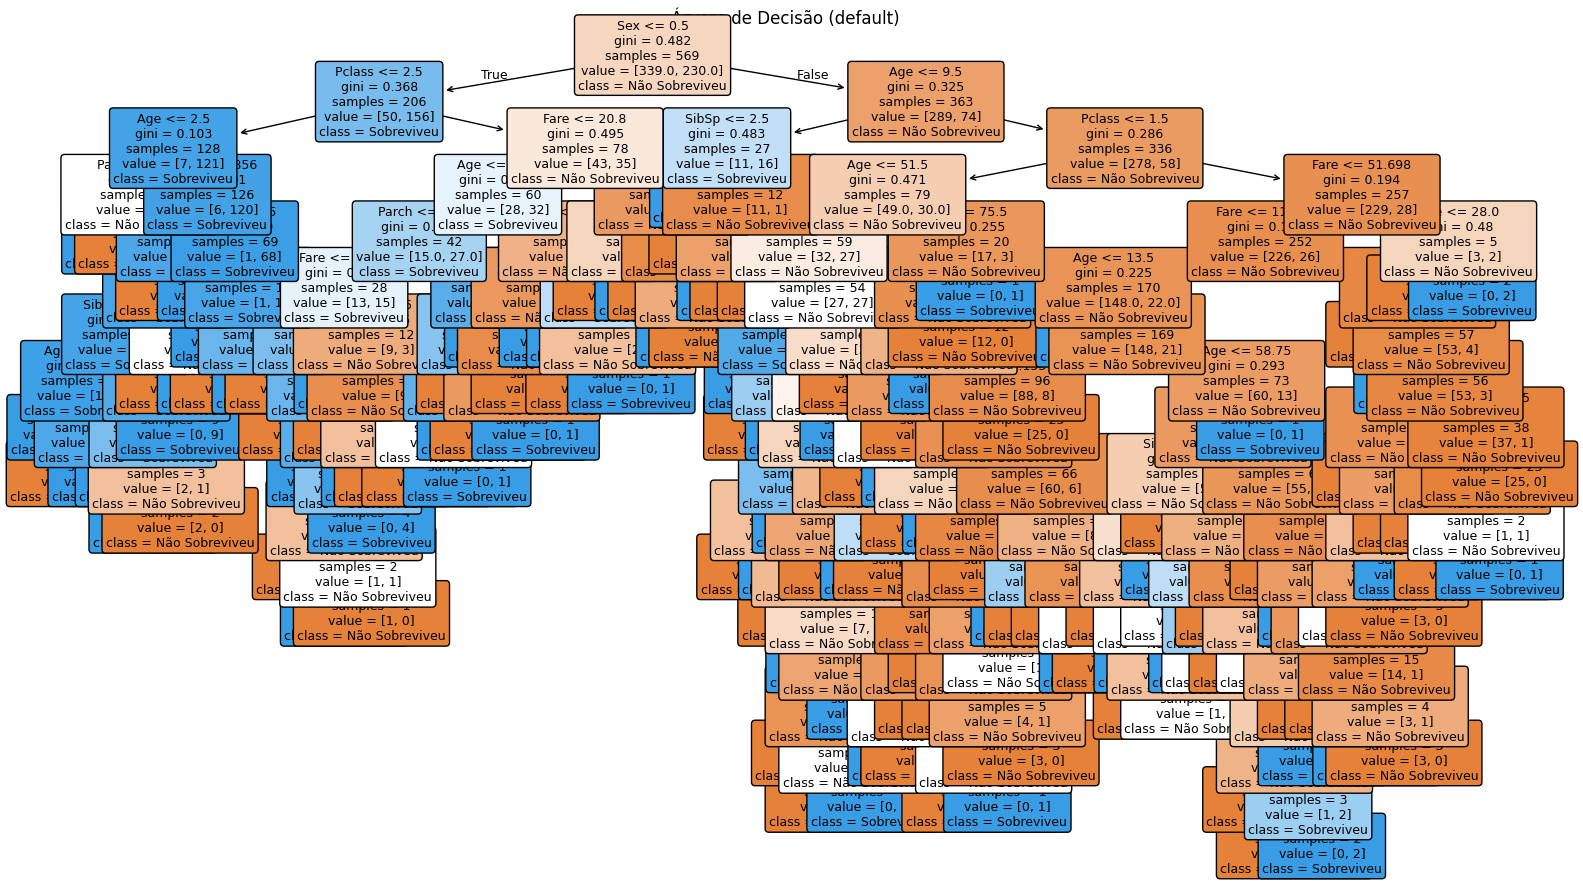

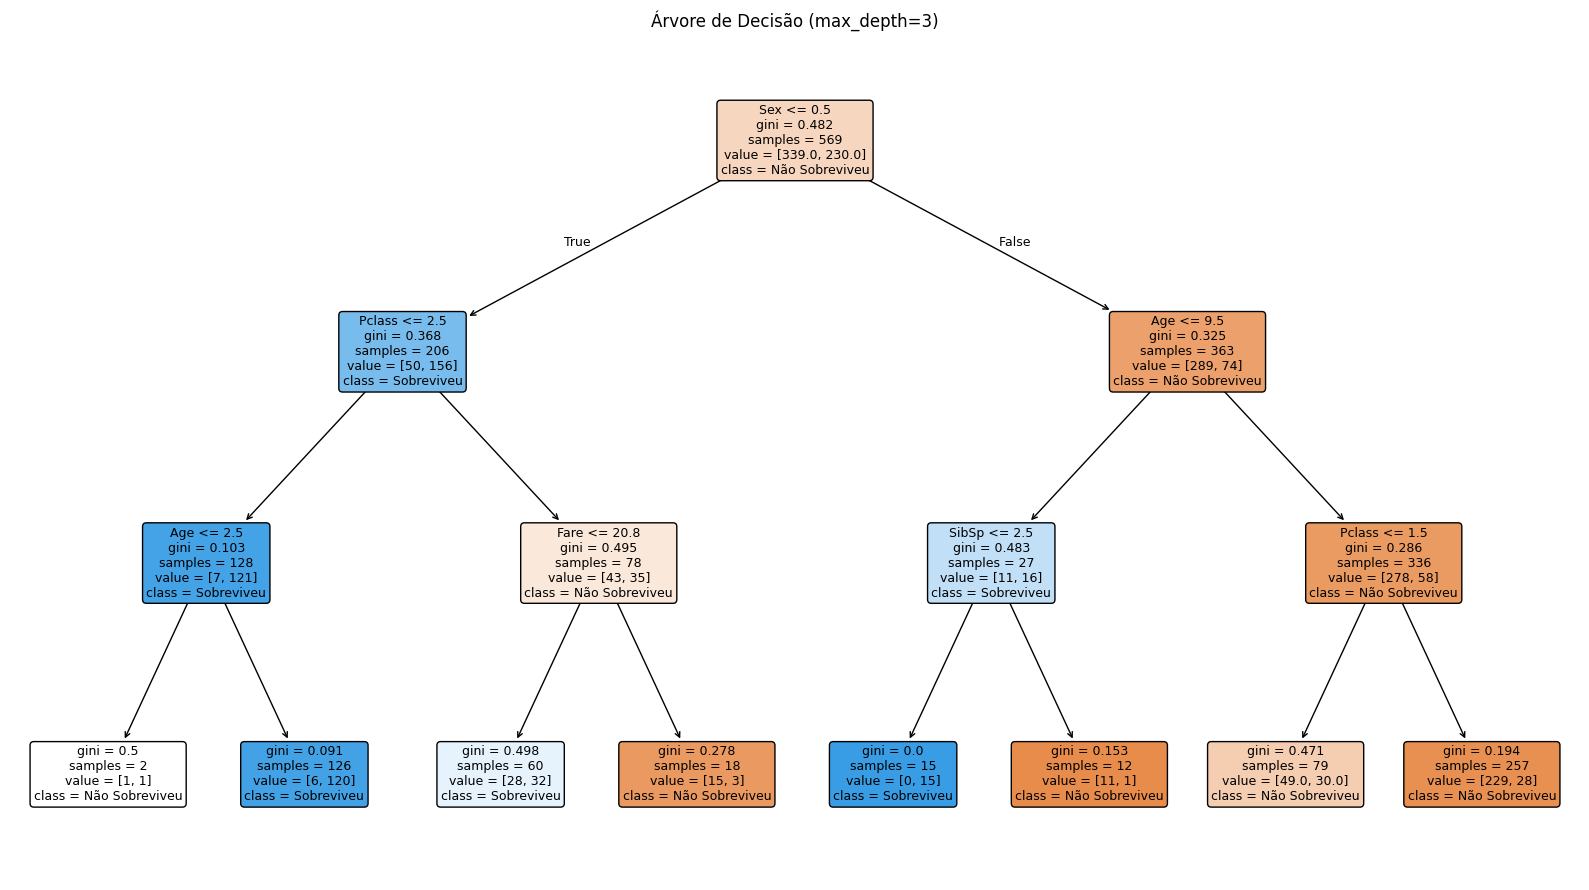

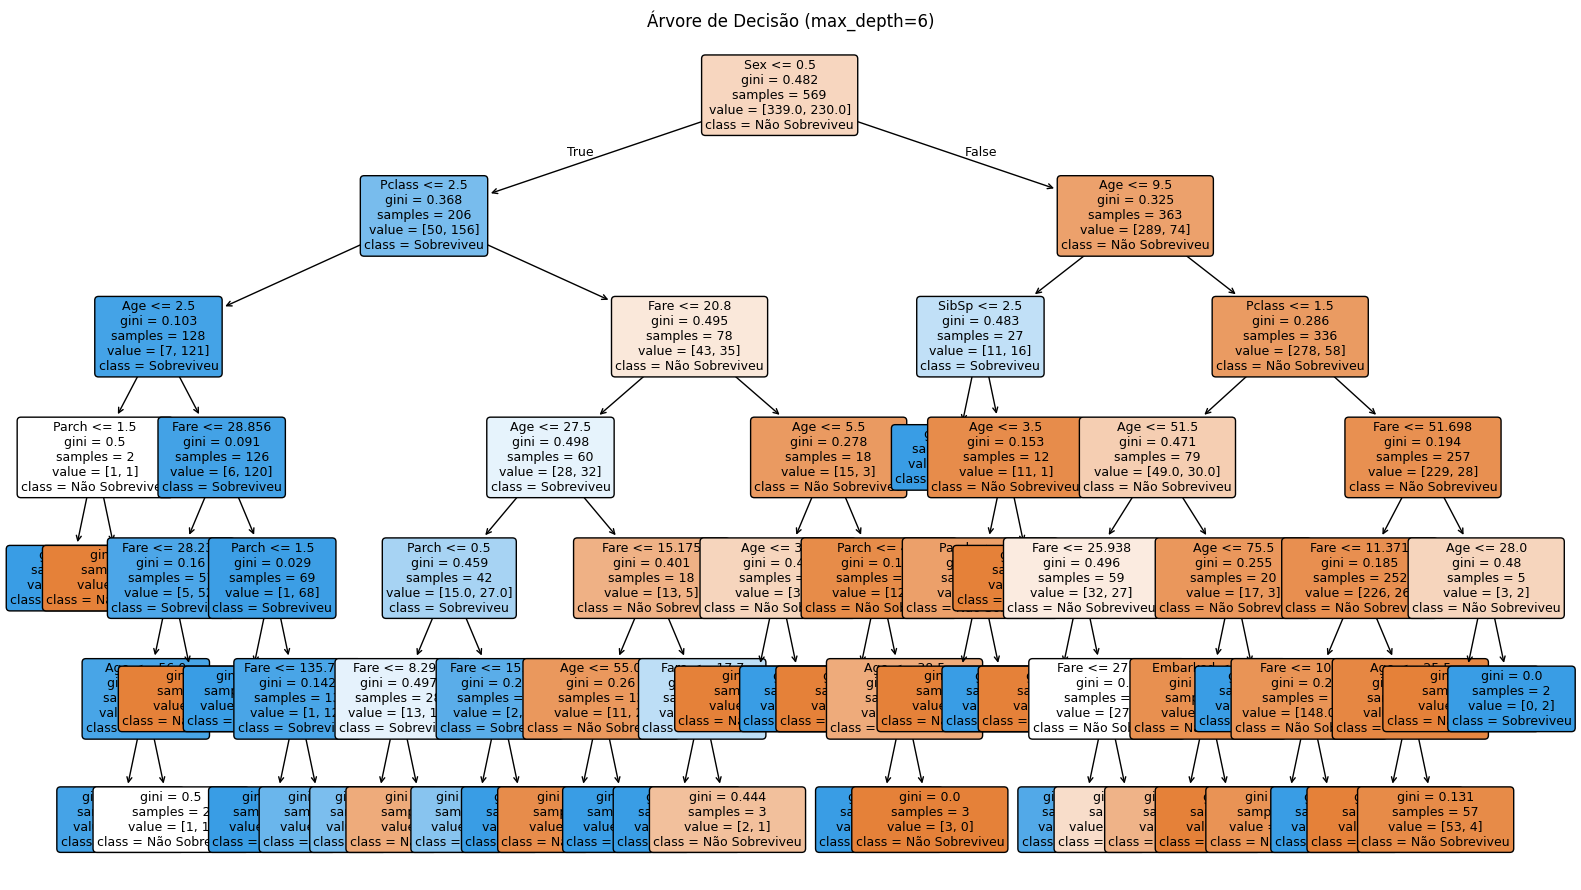

In [ ]:
# Q4 — Visualizações das árvores
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

def plotar_arvore(modelo, titulo, fname):
    plt.figure(figsize=(16,9))
    plot_tree(modelo, feature_names=X.columns,
              class_names=["Não Sobreviveu", "Sobreviveu"],
              filled=True, rounded=True, fontsize=9)
    plt.title(titulo)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

# Modelos para plot
modelo_default_plot = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
modelo_d3_plot = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
modelo_d6_plot = DecisionTreeClassifier(max_depth=6, random_state=42).fit(X_train, y_train)

plotar_arvore(modelo_default_plot, "Árvore de Decisão (default)", "q4_arvore_default.png")
plotar_arvore(modelo_d3_plot, "Árvore de Decisão (max_depth=3)", "q4_arvore_depth_3.png")
plotar_arvore(modelo_d6_plot, "Árvore de Decisão (max_depth=6)", "q4_arvore_depth_6.png")


**Análise (Q4):**  

>As árvores deixam claro o dilema **interpretabilidade × complexidade/profundidade**. A árvore **`default`** cresce mais profundamente, capturando padrões finos, porém suscetível a _ruídos_ e _overfitting_. Com profundidades controladas ganhamos versões mais legíveis e comparáveis:

- **`max_depth=3`** → estrutura mais explicável, menos nós, menor variância e melhor capacidade de generalização.
- **`max_depth=6`** → mais ramificações que podem capturar interações úteis, mas com maior risco de superajuste.

>Em resumo, a escolha de `max_depth` deve alinhar objetivo do negócio e governança do modelo: modelos mais rasos priorizam _clareza_ e _robustez_; modelos mais profundos buscam margem de performance assumindo maior risco de variância. A escolha depende do **trade‑off** entre desempenho e interpretabilidade.  

📁 **Figuras salvas**: `q4_arvore_default.png`, `q4_arvore_depth_3.png`, `q4_arvore_depth_6.png`.


---
### Arquivos de figuras gerados
- Q2: `q2_matriz_confusao_default.png`  
- Q3: `q3_matriz_confusao_depth_3.png`, `q3_matriz_confusao_depth_6.png`  
- Q4: `q4_arvore_default.png`, `q4_arvore_depth_3.png`, `q4_arvore_depth_6.png`

As imagens são salvas no **diretório de execução** do notebook. No Colab, você pode baixá-las pelo painel de arquivos (ícone de pasta) ou usando `from google.colab import files; files.download('arquivo.png')`.
